# Fuel Consumption Prediction of Vehicles

## Objective
The goal of this project is to predict the **fuel consumption (MPG)** of vehicles based on their attributes, including engine specifications, weight, and acceleration.

## Dataset Overview
The dataset contains records of vehicles with features relevant to fuel efficiency prediction.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for fuel efficiency.
4. **Model Training**: Train a regression model to predict fuel consumption (MPG).
5. **Evaluation**: Assess model performance using RMSE and R² score.

In [33]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
# Load the dataset (auto-mpg.data file)
column_names = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", "car_name"]
df = pd.read_csv('auto-mpg.data',  sep=r'\s+', names=column_names, na_values='?') #replaced delim_whitespace=True due to warning

# Display basic information about the dataset
print("Dataset Information:\n")
print(df.info())

# Display first 5 rows
print("\nFirst 5 Rows:\n")
print(df.head())

# Check basic statistics
print("\nSummary Statistics:\n")
print(df.describe())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB
None

First 5 Rows:

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0     

## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

Missing values in each column:

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


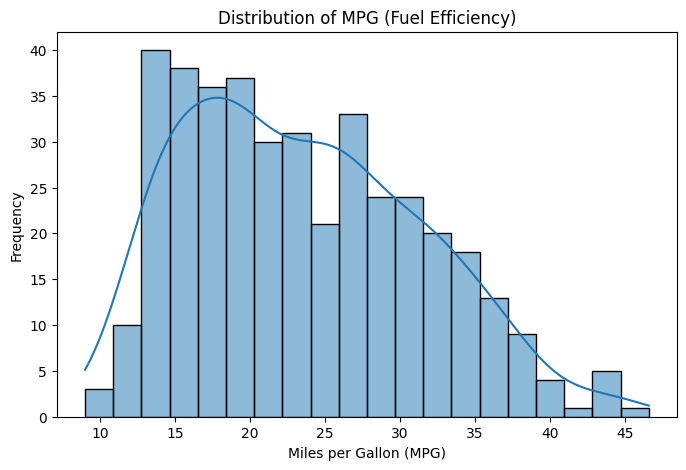

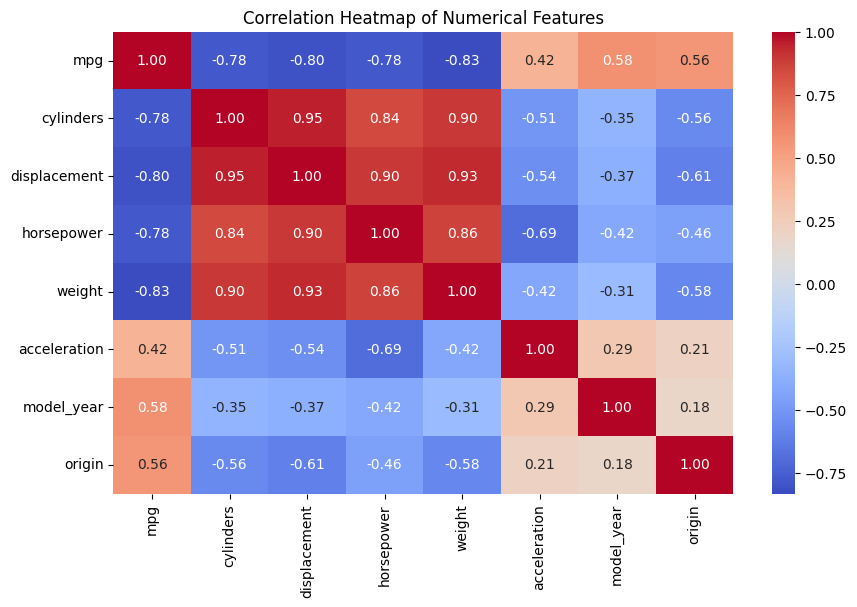

In [35]:
# Check for missing values
print("Missing values in each column:\n")
print(df.isnull().sum())

# Visualize MPG distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['mpg'], bins=20, kde=True)
plt.title("Distribution of MPG (Fuel Efficiency)")
plt.xlabel("Miles per Gallon (MPG)")
plt.ylabel("Frequency")
plt.show()

# Correlation heatmap (numerical features only)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [36]:
#Handling missing values
# Drop rows with missing values
df = df.dropna()

# Verify if missing values are removed
print("\nAfter dropping missing values:\n")
print(df.isnull().sum())

# Check unique values
print("Unique values in origin column before encoding:")
print(df['origin'].unique())

# Encode categorical variables (Origin as categorical feature)
# 'origin' represents region codes (1=USA, 2=Europe, 3=Japan)
df['origin'] = df['origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
df = pd.get_dummies(df, columns=['origin'], drop_first=False) 

# See resulting columns
print("\nColumns after encoding:")
print(df.columns)

# Define features (X) and target (y)
# Now define features
feature_cols = ['cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year']

# Add encoded origin columns dynamically
for col in df.columns:
    if col.startswith('origin_'):
        feature_cols.append(col)

# Final features and target
X = df[feature_cols]
y = df['mpg']

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


After dropping missing values:

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64
Unique values in origin column before encoding:
[1 3 2]

Columns after encoding:
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'car_name', 'origin_Europe',
       'origin_Japan', 'origin_USA'],
      dtype='object')
Training set shape: (313, 9)
Testing set shape: (79, 9)


## Model Training
Train a **Linear Regression** model to predict fuel consumption.


Model Evaluation Results:
Mean Squared Error (MSE): 10.60
Root Mean Squared Error (RMSE): 3.26
R² Score: 0.7923


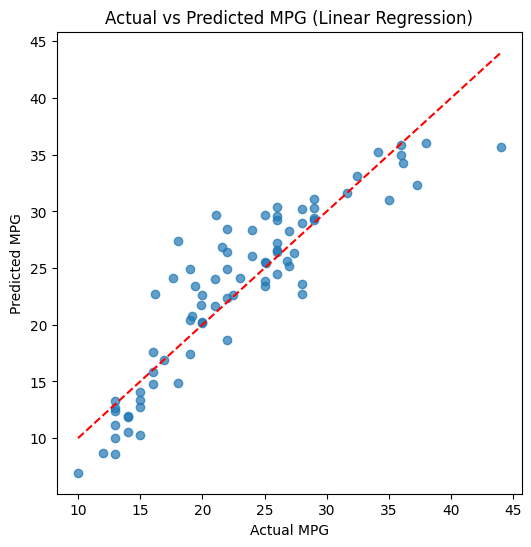

In [37]:
# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Results:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Compare predicted vs actual visually
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG (Linear Regression)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()